In [2]:
import time as tm
import numpy as np
from datetime import datetime
import os
import sys

# Importation de la configuration des chemins
ROOT_DIR = "/gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path"
import pandas as pd



# Choix de la HSS

In [60]:
import numpy as np
import pandas as pd

num_storm = 25
fichier_obs_path = ROOT_DIR + f"/test_constantin/Entrainement_RNN/32STORMS_DATA/HSS{num_storm}.dat"
# Chargement
data = np.loadtxt(fichier_obs_path)
df = pd.DataFrame(data, columns=['Kp','t','L','alpha','E','Daa'])
df[['Kp','t','L']] = df[['Kp','t','L']].astype(int)

# Ensemble des L présents
L_vals = sorted(df.L.unique())

print(f"=== Analyse des dimensions par L pour HSS {num_storm} ===\n")

for L in L_vals:
    df_L = df[df['L'] == L]

    # Dimensions globales
    alpha_vals = sorted(df_L.alpha.unique())
    E_vals = sorted(df_L.E.unique())

    n_alpha = len(alpha_vals)
    n_E = len(E_vals)

    print(f"--- L = {L} ---")
    print(f"  Nombre distinct de alpha : {n_alpha}")
    print(f"  Nombre distinct de E     : {n_E}")
    print(f"  Nombre attendu de Daa    : {n_E*n_alpha}")

    # Vérification complète sur toutes les valeurs de t
    t_vals = sorted(df_L.t.unique())

    for t in t_vals:
        df_Lt = df_L[df_L['t'] == t]

        n_alpha_t = df_Lt.alpha.nunique()
        n_E_t = df_Lt.E.nunique()
        n_pts_t = df_Lt.shape[0]
        alpha_min = df_Lt.alpha.min()

        print(f" alpha_min={alpha_min}")


        print(f"total Daa={n_pts_t}")

        # Comparaison avec grille attendue
        expected = n_alpha_t * n_E_t
        if n_pts_t != expected:
            print(f"Manque des valeurs :  {expected - n_pts_t}")

    print()


=== Analyse des dimensions par L pour HSS 25 ===

--- L = 2 ---
  Nombre distinct de alpha : 254
  Nombre distinct de E     : 60
  Nombre attendu de Daa    : 15240
 alpha_min=18.8365487884789
total Daa=15177
Manque des valeurs :  3
 alpha_min=18.8365487884789
total Daa=15176
Manque des valeurs :  4
 alpha_min=18.8365487884789
total Daa=15235
Manque des valeurs :  5
 alpha_min=18.8365487884789
total Daa=15233
Manque des valeurs :  7
 alpha_min=18.8365487884789
total Daa=15176
Manque des valeurs :  4
 alpha_min=18.8365487884789
total Daa=15229
Manque des valeurs :  11
 alpha_min=18.8365487884789
total Daa=15176
Manque des valeurs :  4
 alpha_min=18.8365487884789
total Daa=15176
Manque des valeurs :  4
 alpha_min=18.8365487884789
total Daa=15231
Manque des valeurs :  9

--- L = 3 ---
  Nombre distinct de alpha : 254
  Nombre distinct de E     : 60
  Nombre attendu de Daa    : 15240
 alpha_min=10.4515167994044
total Daa=15232
Manque des valeurs :  8
 alpha_min=10.4515167994044
total Daa=15

In [61]:
# Filtrer la tempête 31 et L=2
df_L = df[df['L'] == 2]

# Trier par alpha et E pour avoir l'ordre des colonnes
df_L_sorted = df_L.sort_values(by=['alpha','E']).reset_index(drop=True)

# Indices pour la première et la dernière colonne (en considérant E variant plus vite que alpha)
# Ici 253 valeurs => index 0 et index 252
first_col = df_L_sorted[df_L_sorted['alpha'] == df_L_sorted['alpha'].min()]
last_col  = df_L_sorted[df_L_sorted['alpha'] == df_L_sorted['alpha'].max()]

print("Première colonne (alpha_min):")
print(first_col)

print("\nDernière colonne (alpha_max):")
print(last_col)


Première colonne (alpha_min):
     Kp   t  L      alpha         E        Daa
0     0  16  2  18.836549 -1.132746  -9.460425
1     0  18  2  18.836549 -1.132746 -10.468706
2     1  17  2  18.836549 -1.132746 -10.725462
3     3  11  2  18.836549 -1.132746  -8.662618
4     3  12  2  18.836549 -1.132746  -8.826638
..   ..  .. ..        ...       ...        ...
535   3  12  2  18.836549  0.777976  -6.186855
536   3  13  2  18.836549  0.777976  -7.560346
537   4  10  2  18.836549  0.777976  -6.146323
538   4  14  2  18.836549  0.777976  -6.544758
539   4  15  2  18.836549  0.777976  -6.625688

[540 rows x 6 columns]

Dernière colonne (alpha_max):
        Kp   t  L      alpha         E        Daa
136596   3  12  2  89.574685 -0.444301 -12.322151
136597   3  12  2  89.574685 -0.350056 -11.079033
136598   3  12  2  89.574685 -0.269973 -10.667524
136599   3  13  2  89.574685 -0.269973 -12.330812
136600   3  12  2  89.574685 -0.200638 -10.306388
...     ..  .. ..        ...       ...        ...
1

In [62]:
# Récupérer les lignes alpha max existantes
last_col = df_L_sorted[df_L_sorted['alpha']== df_L_sorted['alpha'].max()]

# Dupliquer ces lignes et mettre alpha à la nouvelle valeur
new_alpha_val = 89.554629
dup_col = last_col.copy()
dup_col['alpha'] = new_alpha_val

# Ajouter les lignes dupliquées au dataframe
df = pd.concat([df, dup_col], ignore_index=True)


In [63]:
df_L = df[df['L'] == 2]
print(df_L['alpha'].nunique())  # devrait maintenant afficher 254


255


In [39]:

# Ensemble des L présents
L_vals = sorted(df.L.unique())

print(f"=== Analyse des dimensions par L pour HSS {num_storm} ===\n")

for L in L_vals:
    df_L = df[df['L'] == L]

    # Dimensions globales
    alpha_vals = sorted(df_L.alpha.unique())
    E_vals = sorted(df_L.E.unique())

    n_alpha = len(alpha_vals)
    n_E = len(E_vals)

    print(f"--- L = {L} ---")
    print(f"  Nombre distinct de alpha : {n_alpha}")
    print(f"  Nombre distinct de E     : {n_E}")
    print(f"  Nombre attendu de Daa    : {n_E*n_alpha}")

    # Vérification complète sur toutes les valeurs de t
    t_vals = sorted(df_L.t.unique())

    for t in t_vals:
        df_Lt = df_L[df_L['t'] == t]

        n_alpha_t = df_Lt.alpha.nunique()
        n_E_t = df_Lt.E.nunique()
        n_pts_t = df_Lt.shape[0]
        alpha_min = df_Lt.alpha.min()

        print(f" alpha_min={alpha_min}")


        print(f"total Daa={n_pts_t}")

        # Comparaison avec grille attendue
        expected = n_alpha_t * n_E_t
        if n_pts_t != expected:
            print(f"Manque des valeurs :  {expected - n_pts_t}")

    print()

=== Analyse des dimensions par L pour HSS 31 ===

--- L = 2 ---
  Nombre distinct de alpha : 254
  Nombre distinct de E     : 60
  Nombre attendu de Daa    : 15240
 alpha_min=18.8365487884789
total Daa=15233
Manque des valeurs :  7
 alpha_min=18.8365487884789
total Daa=15235
Manque des valeurs :  5
 alpha_min=18.8365487884789
total Daa=15235
Manque des valeurs :  5
 alpha_min=18.8365487884789
total Daa=15233
Manque des valeurs :  7
 alpha_min=18.8365487884789
total Daa=15231
Manque des valeurs :  9
 alpha_min=18.8365487884789
total Daa=15233
Manque des valeurs :  7
 alpha_min=18.8365487884789
total Daa=15227
Manque des valeurs :  13
 alpha_min=18.8365487884789
total Daa=15233
Manque des valeurs :  7
 alpha_min=18.8365487884789
total Daa=15227
Manque des valeurs :  13

--- L = 3 ---
  Nombre distinct de alpha : 254
  Nombre distinct de E     : 60
  Nombre attendu de Daa    : 15240
 alpha_min=10.4515167994044
total Daa=15235
Manque des valeurs :  5
 alpha_min=10.4515167994044
total Daa=1

In [40]:
#output_path = "/gpfs/users/godardc/HSS31_debug.dat"
#df.to_csv(output_path, sep=' ', index=False, header=False)


# Valeur minimale de alpha par L 
L = 2 => alpha_min = 18.8365487884789° <br>
L = 3 => alpha_min = 10.4515167994044°<br>
L = 4 => alpha_min = 7.6615965721688°<br>
L = 5 => alpha_min = 6.47793781672125°<br>



In [67]:
import numpy as np
import pandas as pd

def init_storm(num_storm):
    """
    Initialise les données d'un HSS donné :
       - charge le fichier .dat
       - construit df
       - calcule les valeurs et dimensions (t, alpha, E)
       - construit la grille (alpha, 10^E)

    Paramètre
    ---------
    num_storm : int
        Numéro du HSS (0–31)

    Retourne
    --------
    dict contenant :
        df, all_t, alpha_vals, E_vals, n_t, n_alpha, n_E, grid_points
    """

    fichier_obs_path = ROOT_DIR + f"/test_constantin/Entrainement_RNN/32STORMS_DATA/HSS{num_storm}.dat"

    # Charger
    data = np.loadtxt(fichier_obs_path)
    df = pd.DataFrame(data, columns=['Kp','t','L','alpha','E','Daa'])
    df[['Kp','t','L']] = df[['Kp','t','L']].astype(int)

    # Valeurs distinctes
    all_t = sorted(df.t.unique())
    alpha_vals = sorted(df.alpha.unique())
    E_vals = sorted(df.E.unique())

    # Dimensions
    n_t = len(all_t)
    n_alpha = len(alpha_vals)
    n_E = len(E_vals)

    # Grille (alpha, 10^E)
    alpha_grid, E_grid = np.meshgrid(alpha_vals, E_vals, indexing='ij')
    grid_points = np.column_stack((alpha_grid.ravel(), 10**E_grid.ravel()))

    return {
        "df": df,
        "all_t": all_t,
        "alpha_vals": alpha_vals,
        "E_vals": E_vals,
        "n_t": n_t,
        "n_alpha": n_alpha,
        "n_E": n_E,
        "grid_points": grid_points
    }


In [68]:
init_storm(num_storm)['df']

,Kp,t,L,alpha,E,Daa
0,0,15,2,18.836549,-1.132746,-10.708484
1,0,15,2,18.836549,-0.881499,-11.051685
2,0,15,2,18.836549,-0.698900,-11.314926
3,0,15,2,18.836549,-0.557853,-11.542597
4,0,15,2,18.836549,-0.444301,-11.737817
...,...,...,...,...,...,...
426880,4,10,3,89.558073,0.746504,-11.303622
426881,4,10,3,89.558073,0.754587,-11.257276
426882,4,10,3,89.558073,0.762524,-11.208597
426883,4,10,3,89.558073,0.770318,-11.162876


In [69]:
def_range = df[(df['L']==4)&(df['t']==10)]
alphas = np.sort(def_range['alpha'].unique())
E = np.sort(def_range['E'].unique())
print(len(alphas))
print(len(E))



0
0


In [70]:
import numpy as np
import pandas as pd
from itertools import product

# fonction utilitaire nearest neighbor
def nearest_value(a, e, df):
    if df.empty or df['Daa'].dropna().empty:
        return np.nan  # ou une autre valeur par défaut
    d = np.sqrt((df['alpha'] - a)**2 + (df['E'] - e)**2)
    return df.loc[d.idxmin(), 'Daa']


def remplissage(sous_df, df_ref):

    sous_df = sous_df.copy()

    # Vérification rapide : aucune valeur disponible
    if sous_df['Daa'].dropna().empty:
        # Matrice de taille attendue : alpha × E
        def_range = df_ref[(df_ref["L"] == 2) & (df_ref["t"] == 10)]
        alphas = np.sort(def_range['alpha'].unique())
        Es = np.sort(def_range['E'].unique())

        n_total = len(alphas) * len(Es)
        return np.full(n_total, -15.0)

    # Sinon : on continue le code normal

    def_range = df_ref[(df_ref["L"] == 2) & (df_ref["t"] == 10)]
    alphas = np.sort(def_range['alpha'].unique())
    Es = np.sort(def_range['E'].unique())

    full = pd.DataFrame(list(product(alphas, Es)), columns=['alpha', 'E'])
    merged = full.merge(sous_df[['alpha','E','Daa']], on=['alpha','E'], how='left')

    missing_idx = merged[merged['Daa'].isna()].index

    for idx in missing_idx:
        a = merged.at[idx, 'alpha']
        e = merged.at[idx, 'E']

        grp_E = sous_df[sous_df['alpha'] == a].sort_values('E')
        if len(grp_E) >= 2 and grp_E['E'].min() <= e <= grp_E['E'].max():
            merged.at[idx, 'Daa'] = np.interp(e, grp_E['E'].values, grp_E['Daa'].values)
            continue

        grp_a = sous_df[sous_df['E'] == e].sort_values('alpha')
        if len(grp_a) >= 2 and grp_a['alpha'].min() <= a <= grp_a['alpha'].max():
            merged.at[idx, 'Daa'] = np.interp(a, grp_a['alpha'].values, grp_a['Daa'].values)
            continue

        val = nearest_value(a, e, sous_df)
        merged.at[idx, 'Daa'] = -15.0 if pd.isna(val) else val

    pivot = merged.pivot(index='alpha', columns='E', values='Daa')
    matrice = pivot.values
    return matrice.ravel()


In [71]:
def remplissage_full(df, L_min=2, L_max=5, t_min=10, t_max=18):
    """
    Construit une matrice de snapshots remplis pour tous les couples (L, t).

    Paramètres
    ----------
    df : DataFrame
        Données contenant les colonnes ['L','t','alpha','E','Daa'].
    L_min, L_max : int
        Bornes de L (inclusif).
    t_min, t_max : int
        Bornes de t (inclusif).

    Retour
    ------
    snapshots : np.ndarray
        Tableau 3D de taille (n_points, n_t, n_L)
    """

    snapshots = []

    L_values = list(range(L_min, L_max + 1))
    t_values = list(range(t_min, t_max + 1))

    for L in L_values:
        snapshots_L = []
        for t in t_values:
            snapshot_df = df[(df["L"] == L) & (df["t"] == t)]
            filled = remplissage(snapshot_df,df)  # ta fonction existante
            snapshots_L.append(filled)
        snapshots.append(snapshots_L)
        print(f"L-shell n°{L} completed")

    # Convertir en numpy array
    snapshots = np.array(snapshots)   # shape : (n_L, n_t, n_points)

    # On remet dans l'ordre (n_points, n_t, n_L) comme avant
    snapshots = snapshots.transpose(2, 1, 0)

    return snapshots


In [72]:
snapshots_matrix = remplissage_full(init_storm(num_storm)['df'])

print(snapshots_matrix.shape)


L-shell n°2 completed
L-shell n°3 completed
L-shell n°4 completed
L-shell n°5 completed
(15240, 9, 4)


In [73]:
np.save(f"snapshots_matrix_HSS{num_storm}.npy", snapshots_matrix)
snapshots_matrix[:, 0, 0]

array([-10.62144744, -10.97855583, -11.24045325, ...,  -9.01021177,
        -9.01727271,  -9.02531464])

# Chargement des données complétées

In [74]:
import time as tm
import numpy as np
from datetime import datetime
import os
import sys

# Importation de la configuration des chemins
ROOT_DIR = "/gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path"
import pandas as pd
num_storm = 0
#np.save(f"snapshots_matrix_HSS{num_storm}.npy", snapshots_matrix)
#snapshots_matrix[:, 0, 0]



# Chargement du fichier
snapshots_matrix = np.load(f"snapshots_matrix_HSS{num_storm}.npy")

# Affichage des dimensions
print("Dimensions :", snapshots_matrix.shape)


Dimensions : (15240, 9, 4)


[-4.654242   -4.18076781 -4.255158   ... -6.45987749 -6.48147562
 -6.50208631]


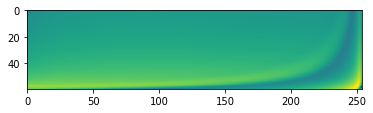

In [77]:
# vecteur, t, L-shell
import matplotlib.pyplot as plt
test_snap = snapshots_matrix[:, 3, 2]
print(test_snap)
#print(test_snap.shape)
photo = test_snap.reshape(254,60)
plt.jet
plt.imshow(np.rot90(photo, k=1))


In [78]:
# snapshots_matrix : shape (15240, 10, 4)

t_vals = list(range(10, 19))  # 10 → 19
L_vals = list(range(2, 6))    # 2 → 5

print("Couples (t, L) ayant au moins une valeur égale à -15 :\n")

for t_idx, t in enumerate(t_vals):
    for L_idx, L in enumerate(L_vals):

        snapshot = snapshots_matrix[:, t_idx, L_idx]

        if np.any(snapshot == -15):
            print(f"  → t = {t}, L = {L}   (zéros = {np.sum(snapshot==0)})")


Couples (t, L) ayant au moins une valeur égale à -15 :

  → t = 10, L = 4   (zéros = 0)
  → t = 10, L = 5   (zéros = 0)
  → t = 11, L = 4   (zéros = 0)
  → t = 11, L = 5   (zéros = 0)
  → t = 12, L = 5   (zéros = 0)
  → t = 13, L = 5   (zéros = 0)
  → t = 16, L = 5   (zéros = 0)
  → t = 17, L = 5   (zéros = 0)


In [79]:
snapshots_matrix[:,0,3]

array([-15., -15., -15., ..., -15., -15., -15.])

In [80]:
# snapshots_matrix : shape (15240, 10, 4)
print(snapshots_matrix.shape)


(15240, 9, 4)


## Lancement d'une POD avec des poids

In [81]:
import numpy as np
import matplotlib.pyplot as plt

import importlib
import POD
import RBF


from POD import POD 
pod = POD()

from RBF import RBFInterpolator



In [82]:
def run_POD_RBF_for_L(snapshots_matrix_L, t_min=10, t_max=18, n_interp=100):
    """
    Applique POD + RBF + reconstruction pour un L donné.

    Paramètres
    ----------
    snapshots_matrix_L : np.ndarray
        Matrice 2D ou 3D contenant les snapshots (n_points, n_t) ou (n_points, n_t, 1)
    t_min, t_max : int
        Intervalle réel de temps correspondant aux snapshots
    n_interp : int
        Nombre de valeurs interpolées pour l'évaluation RBF
    plot : bool
        Si True, affiche quelques snapshots reconstruits

    Retour
    ------
    states_reconstructed : np.ndarray
        États reconstruits interpolés : shape (n_interp, n_points)
    """

    # --- Mise en forme ---
    if snapshots_matrix_L.ndim == 3:
        snapshots_matrix_L = snapshots_matrix_L[:, :, 0]  # retirer axe inutile

    n_points, n_t = snapshots_matrix_L.shape


    # --- Détection des snapshots artificiels ---
    mask_bad = np.all(snapshots_matrix_L == -15, axis=0)
    weights = np.ones(n_t)
    weights[mask_bad] = 0.6   # fort downweight des faux snapshots


    # Paramètres t utilisés pour l'entraînement
    t_train = np.linspace(t_min, t_max, n_t).reshape(-1, 1)

    # --- POD ---
    pod = POD()
    pod.compute(snapshots_matrix_L, energy_ratio=0.999, weights=weights)

    coeffs = pod.project(snapshots_matrix_L)

    # --- RBF interpolation ---
    rbf = RBFInterpolator()
    rbf.fit(t_train, coeffs, sample_weight=weights)

    # Paramètres intermédiaires
    t_interp = np.linspace(t_min, t_max, n_interp).reshape(-1, 1)

    # Prédiction des coefficients POD interpolés
    coeffs_interp = rbf.predict(t_interp)

    # Reconstruction des snapshots
    states = pod.reconstruct(coeffs_interp)

    # Mise en forme (n_interp, n_points)
    states = states
    
    return states


In [83]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
from matplotlib.animation import FFMpegWriter

import matplotlib as mpl
mpl.rcParams['animation.ffmpeg_path'] = '/gpfs/softs/spack_0.17/opt/spack/linux-centos7-cascadelake/gcc-11.2.0/ffmpeg-4.3.2-nhihmidor4i3bdfcyditksvomdupaipc/bin/ffmpeg'



def creation_video(states, y_spline, L, filename=None, fps=10):
    """
    Crée une vidéo à partir d'une séquence de snapshots reconstruits.

    Paramètres
    ----------
    states : ndarray (n_frames, 254, 60)
        Snapshots reconstruits par POD+RBF.

    y_spline : ndarray (n_frames,)
        Valeurs interpolées de Kp associées à chaque frame.

    L : int
        Indice L correspondant aux données (pour les titres / nom du fichier).

    filename : str, optionnel
        Nom du fichier vidéo. Par défaut : 'video_L{L}.mp4'.

    fps : int
        Nombre d'images par seconde dans la vidéo.
    """

    n_frames = states.shape[0]

    if filename is None:
        filename = f"video_L{L}.mp4"

    # --- Figure ---
    fig, (ax_img, ax_kp) = plt.subplots(
        2, 1, figsize=(6, 7),
        gridspec_kw={'height_ratios': [8, 1]}
    )
    plt.subplots_adjust(hspace=0.4)

    # --- Image principale ---
    cNorm = matplotlib.colors.Normalize(vmin=-9, vmax=-4)
    cmap = plt.cm.jet

    im = ax_img.imshow(np.rot90(states[0], k=1), cmap=cmap, norm=cNorm, aspect='auto')
    ax_img.set_title(fr"$\log(D_{{\alpha\alpha}})$ interpolé – L = {L}")

    # --- Colorbar ---
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=cNorm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax_img, orientation='vertical',
                 fraction=0.046, pad=0.04,
                 label=r"$\log(D_{\alpha\alpha})$")

    # --- Barre Kp ---
    ax_kp.set_xlim(0, 6)
    ax_kp.set_ylim(0, 1)
    ax_kp.set_yticks([])
    ax_kp.set_xlabel("$K_p$ index")

    bar = ax_kp.barh(0.5, y_spline[0], height=0.3, color='dodgerblue')
    kp_marker = ax_kp.axvline(y_spline[0], color='red', lw=2, linestyle='--')

    # --- Textes explicatifs ---
    text_time = ax_kp.text(
        0.1, 1.12, "", ha='center', va='bottom', fontsize=12,
        transform=ax_kp.transAxes,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )
    text_kp = ax_kp.text(
        0.9, 1.12, "", ha='center', va='bottom', fontsize=12,
        transform=ax_kp.transAxes,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

    # --- Fonction de mise à jour ---
    def update(frame):
        # Image
        im.set_array(np.rot90(states[frame], k=1))

        # t interpolé
        t = 9 * frame / (n_frames - 1)
        Kp = y_spline[frame]

        # Jauge
        bar[0].set_width(Kp)
        kp_marker.set_xdata(Kp)

        # Textes
        text_time.set_text(f"$t$ = {t:.2f}")
        text_kp.set_text(f"$K_p$ = {Kp:.2f}")

        return [im, bar[0], kp_marker, text_time, text_kp]

    # --- Animation ---
    ani = animation.FuncAnimation(
        fig, update, frames=n_frames, interval=100, blit=True
    )

    writer = FFMpegWriter(fps=fps, codec='mpeg4', bitrate=15000)
    ani.save(filename, writer=writer, dpi=350)

    plt.close()
    print(f"Vidéo sauvegardée : {filename}")


In [20]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import pandas as pd

ROOT_DIR = "/gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path"


def load_Kp_sequences():
    base_dir = os.path.join(ROOT_DIR, "Frontiers21", "UNI_PARIS_SACLAY_ARTICLE", "32STORMS_DATA", "DAA2D_HSS")
    data_list = []
    for i in range(1, 33):
        file_path = base_dir + f"{i}_Storm/Kp_sequence.dat"
        sequence_file = file_path
        print(f"Loading {sequence_file}...")
        if not os.path.exists(sequence_file):
            print(f"Warning: {sequence_file} not found.")
            continue
        try:
            # Load the sequence as numbers from the file.
            sequence = np.loadtxt(sequence_file)
        except Exception as e:
            print(f"Error reading {sequence_file}: {e}")
            sequence = None
        data_list.append({
            "storm_id": i,
            "sequence": sequence
        })
    df_sequences = pd.DataFrame(data_list)
    return df_sequences


df_kp = load_Kp_sequences()
print(df_kp)


num_storm =0
# Récupération de la séquence
sequence = df_kp.loc[df_kp['storm_id'] == num_storm +1, 'sequence'].iloc[0]

# Points d'origine
x = np.arange(0, len(sequence))

# Création du spline cubique
# s=0 → passe exactement par tous les points
spline = UnivariateSpline(x, sequence, s=0)

# Création de 100 points entre 0 et 9
x_spline = np.linspace(0, len(sequence)-1, 100)
y_spline = spline(x_spline)



Loading /gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/Frontiers21/UNI_PARIS_SACLAY_ARTICLE/32STORMS_DATA/DAA2D_HSS1_Storm/Kp_sequence.dat...
Loading /gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/Frontiers21/UNI_PARIS_SACLAY_ARTICLE/32STORMS_DATA/DAA2D_HSS2_Storm/Kp_sequence.dat...
Loading /gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/Frontiers21/UNI_PARIS_SACLAY_ARTICLE/32STORMS_DATA/DAA2D_HSS3_Storm/Kp_sequence.dat...
Loading /gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/Frontiers21/UNI_PARIS_SACLAY_ARTICLE/32STORMS_DATA/DAA2D_HSS4_Storm/Kp_sequence.dat...
Loading /gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/Frontiers21/UNI_PARIS_SACLAY_ARTICLE/32STORMS_DATA/DAA2D_HSS5_Storm/Kp_sequence.dat...
Loading /gpfs/users/godardc/hinge/Donnees_Guillaume_path/Donnees_Guillaume_path/Frontiers21/UNI_PARIS_SACLAY_ARTICLE/32STORMS_DATA/DAA2D_HSS6_Storm/Kp_sequence.dat..

In [85]:
"""# --- Choix de L ---
L_vals = [2, 3, 4, 5]   # valeurs réelles de L
L = 2                    # L fixé
L_index = L_vals.index(L)  # trouver l'indice correspondant dans snapshots_matrix

# --- Extraire les snapshots pour ce L ---
snap_L = snapshots_matrix[:, :, L_index]  # shape (n_points, n_t)

# --- Appliquer POD + RBF pour reconstruire les snapshots interpolés ---
states = run_POD_RBF_for_L(snap_L, t_min=10, t_max=18, n_interp=100)  # shape (n_interp, n_points)
states = states.reshape(100, 254, 60)
"""

#creation_video(states, y_spline, L, filename=f"video_HSS6_L{L}.mp4", fps=10)


"# --- Choix de L ---\nL_vals = [2, 3, 4, 5]   # valeurs réelles de L\nL = 2                    # L fixé\nL_index = L_vals.index(L)  # trouver l'indice correspondant dans snapshots_matrix\n\n# --- Extraire les snapshots pour ce L ---\nsnap_L = snapshots_matrix[:, :, L_index]  # shape (n_points, n_t)\n\n# --- Appliquer POD + RBF pour reconstruire les snapshots interpolés ---\nstates = run_POD_RBF_for_L(snap_L, t_min=10, t_max=18, n_interp=100)  # shape (n_interp, n_points)\nstates = states.reshape(100, 254, 60)\n"

In [86]:
"""# --- Liste des L à traiter ---
L_vals = [2, 3, 4, 5]

for L in L_vals:
    # Trouver l'indice correspondant dans snapshots_matrix
    L_index = L_vals.index(L)
    
    # Extraire les snapshots pour ce L
    snap_L = snapshots_matrix[:, :, L_index]  # shape (n_points, n_t)
    
    # Appliquer POD + RBF pour reconstruire les snapshots interpolés
    states = run_POD_RBF_for_L(snap_L, t_min=10, t_max=18, n_interp=100)  # shape (n_interp, n_points)
    
    # Remise en forme pour correspondre à (n_interp, n_alpha, n_E)
    states = states.reshape(100, 254, 60)
    
    # Création de la vidéo
    #creation_video(states,y_spline,L,filename=f"video_HSS6_L{L}.mp4",fps=10)
    
"""

'# --- Liste des L à traiter ---\nL_vals = [2, 3, 4, 5]\n\nfor L in L_vals:\n    # Trouver l\'indice correspondant dans snapshots_matrix\n    L_index = L_vals.index(L)\n    \n    # Extraire les snapshots pour ce L\n    snap_L = snapshots_matrix[:, :, L_index]  # shape (n_points, n_t)\n    \n    # Appliquer POD + RBF pour reconstruire les snapshots interpolés\n    states = run_POD_RBF_for_L(snap_L, t_min=10, t_max=18, n_interp=100)  # shape (n_interp, n_points)\n    \n    # Remise en forme pour correspondre à (n_interp, n_alpha, n_E)\n    states = states.reshape(100, 254, 60)\n    \n    # Création de la vidéo\n    #creation_video(states,y_spline,L,filename=f"video_HSS6_L{L}.mp4",fps=10)\n    \n'

In [87]:
snapshots_matrix.shape[0]

15240

### Création d'une vidéo globale pour 4 L-shell

In [88]:
# --- Liste des L à traiter ---
L_vals = [2, 3, 4, 5]

states_all = {}

for idx_L, L in enumerate(L_vals):

    # Extraire la bonne "couche" de snapshots via l'index vertical L
    snap_L = snapshots_matrix[:, :, idx_L]  # shape (n_points, n_t)

    # Reconstruire les états interpolés POD+RBF
    states = run_POD_RBF_for_L(
        snap_L,
        t_min=10,
        t_max=18,
        n_interp=100
    )  # shape (100, n_points)

    # Remise en forme (100, 254, 60)
    if snapshots_matrix.shape[0] == 15180 :
        states = states.reshape(100, 253, 60)

    elif snapshots_matrix.shape[0] == 15240 :
        states = states.reshape(100, 254, 60)

    elif snapshots_matrix.shape[0] == 15300 :
        states = states.reshape(100, 255, 60)

    # On stocke
    states_all[L] = states



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
from matplotlib.animation import FFMpegWriter


def creation_video_all_L(states, y_spline, filename="video_all_L.mp4", fps=10):
    """
    Crée une vidéo unique empilant verticalement les vidéos POD+RBF
    pour L = 2, 3, 4, 5, avec un seul curseur Kp et un seul compteur t.
    
    Paramètres
    ----------
    states : dict {L: ndarray(n_frames, 254, 60)}
        Snapshots pour chaque valeur de L.
        
    y_spline : ndarray (n_frames,)
        Valeurs interpolées de Kp.
        
    filename : str
        Nom du fichier vidéo.
        
    fps : int
        Images par seconde.
    """

    L_vals = [2, 3, 4, 5]
    n_frames = y_spline.shape[0]

    fig, axes_img = plt.subplots(
        4, 1, figsize=(6, 20),
        gridspec_kw={'height_ratios': [1, 1, 1, 1]}
    )

    plt.subplots_adjust(hspace=0.25)

    # --- Axes pour le curseur ---
    ax_kp = fig.add_axes([0.1, 0.02, 0.8, 0.05])  # barre horizontale en bas

    # --- Colorbar ---
    cNorm = matplotlib.colors.Normalize(vmin=-9, vmax=-4)
    cmap = plt.cm.jet

    # Pour la colorbar globale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=cNorm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes_img.ravel().tolist(), orientation='vertical',
                 fraction=0.015, pad=0.02, label=r"$\log(D_{\alpha\alpha})$")

    # --- Initialisation des images (une par L) ---
    ims = []
    for ax, L in zip(axes_img, L_vals):
        ax.set_title(fr"$\log(D_{{\alpha\alpha}})$ interpolé – L = {L}")
        im = ax.imshow(
            np.rot90(states[L][0], k=1),
            cmap=cmap, norm=cNorm, aspect='auto'
        )
        ims.append(im)

    # --- Barre Kp ---
    ax_kp.set_xlim(0, 6)
    ax_kp.set_ylim(0, 1)
    ax_kp.set_yticks([])
    ax_kp.set_xlabel("$K_p$ index")

    bar = ax_kp.barh(0.5, y_spline[0], height=0.3, color='dodgerblue')
    kp_marker = ax_kp.axvline(y_spline[0], color='red', lw=2, linestyle='--')

    # --- Textes globaux ---
    text_time = ax_kp.text(
        0.1, 1.2, "", ha='center', va='bottom', fontsize=12,
        transform=ax_kp.transAxes, bbox=dict(facecolor='white', alpha=0.7)
    )
    text_kp = ax_kp.text(
        0.9, 1.2, "", ha='center', va='bottom', fontsize=12,
        transform=ax_kp.transAxes, bbox=dict(facecolor='white', alpha=0.7)
    )

    # --- Fonction update ---
    def update(frame):
        t = 9 * frame / (n_frames - 1)
        Kp = y_spline[frame]

        # Met à jour chacune des 4 images
        for L, im in zip(L_vals, ims):
            im.set_array(np.rot90(states[L][frame], k=1))

        # Curseur et textes
        bar[0].set_width(Kp)
        kp_marker.set_xdata(Kp)

        text_time.set_text(f"$t$ = {t:.2f}")
        text_kp.set_text(f"$K_p$ = {Kp:.2f}")

        return ims + [bar[0], kp_marker, text_time, text_kp]

    # --- Animation ---
    ani = animation.FuncAnimation(
        fig, update, frames=n_frames, interval=100, blit=True
    )

    writer = FFMpegWriter(fps=10, codec='mpeg4', bitrate=15000)  # bitrate plus élevé
    ani.save(filename, writer=writer, dpi=400)

    plt.close()
    print(f"Vidéo sauvegardée : {filename}")


In [89]:
#creation_video_all_L(states_all, y_spline, filename="video_global.mp4", fps=10)


In [90]:
# --- Liste des L à traiter ---
L_vals = [2, 3, 4, 5]

states_all ={}

for idx_L, L in enumerate(L_vals):

    # Extraire la bonne "couche" de snapshots via l'index vertical L
    snap_L = snapshots_matrix[:, :, idx_L]  # shape (n_points, n_t)

    # Reconstruire les états interpolés POD+RBF
    states = run_POD_RBF_for_L(
        snap_L,
        t_min=10,
        t_max=18,
        n_interp=100
    )  # shape (100, n_points)

    # Remise en forme (100, 254, 60)
    if snapshots_matrix.shape[0] == 15180 :
        states = states.reshape(100, 253, 60)

    elif snapshots_matrix.shape[0] == 15240 :
        states = states.reshape(100, 254, 60)

    elif snapshots_matrix.shape[0] == 15300 :
        states = states.reshape(100, 255, 60)

    # On stocke
    states_all[L] = states



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
from matplotlib.animation import FFMpegWriter


def creation_video_all_L(states, y_spline, filename="video_all_L.mp4", fps=10):
    """
    Crée une vidéo unique empilant verticalement les vidéos POD+RBF
    pour L = 2, 3, 4, 5, avec un seul curseur Kp et un seul compteur t.
    
    Paramètres
    ----------
    states : dict {L: ndarray(n_frames, 254, 60)}
        Snapshots pour chaque valeur de L.
        
    y_spline : ndarray (n_frames,)
        Valeurs interpolées de Kp.
        
    filename : str
        Nom du fichier vidéo.
        
    fps : int
        Images par seconde.
    """

    L_vals = [2, 3, 4, 5]
    n_frames = y_spline.shape[0]

    fig, axes_img = plt.subplots(
        4, 1, figsize=(6, 20),
        gridspec_kw={'height_ratios': [1, 1, 1, 1]}
    )

    fig.suptitle("$\log(D_{\\alpha\\alpha})$ $changes$ $over$ $time$", fontsize=16, y=0.92)
    
    plt.subplots_adjust(hspace=0.25)

    # --- Axes pour le curseur ---
    ax_kp = fig.add_axes([0.1, 0.02, 0.8, 0.05])  # barre horizontale en bas

    # --- Colorbar ---
    cNorm = matplotlib.colors.Normalize(vmin=-9, vmax=-4)
    cmap = plt.cm.jet

    # Pour la colorbar globale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=cNorm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm, 
        ax=axes_img.ravel().tolist(), 
        orientation='vertical',
        fraction=0.1, 
        pad=0.1,
        label=r"$\log(D_{\alpha\alpha})$"
    )

    # Taille de la police pour le label
    cbar.ax.yaxis.label.set_size(14)


    # --- Initialisation des images (une par L) ---
    # --- Dictionnaires visuels comme dans afficher_premiere_frame_all_L ---
    alpha_min_dict = {
        2: 18.8365487884789,
        3: 10.4515167994044,
        4: 7.6615965721688,
        5: 6.47793781672125
    }

    alpha_min_dict2 = {
        2: 20,
        3: 10,
        4: 10,
        5: 10
    }

    alpha_max = 90

    y1 = 10**(-1.13274599535844)
    y2 = 10**(0.777976150405938)

    # --- Initialisation des images avec le même visuel que afficher_premiere_frame_all_L ---
    ims = []
    for ax, L in zip(axes_img, L_vals):

        alpha_min = alpha_min_dict[L]

        im = ax.imshow(
            np.rot90(states[L][0], k=1),
            cmap=cmap,
            norm=cNorm,
            aspect='auto',
            extent=[alpha_min, alpha_max, y1, y2]
        )
        ims.append(im)

        #ax.set_yscale("log")
        ax.set_ylabel("E (MeV)")

        # Axe α commun : 0 → 90, puis resserré comme ta figure statique
        ax.set_xlim(6.47, alpha_max)

        xticks_phys = np.array([alpha_min_dict2[L], 50, 90])
        ax.set_xticks(xticks_phys)
        ax.set_xticklabels([f"{v:d}" for v in xticks_phys])

        ax.set_xlabel(r"$\alpha$ (°)")
        ax.set_title(fr"$L =$ {L}")


    # --- Barre Kp ---
    ax_kp.set_xlim(0, 6)
    ax_kp.set_ylim(0, 1)
    ax_kp.set_yticks([])
    ax_kp.set_xlabel("$K_p$ index")

    bar = ax_kp.barh(0.5, y_spline[0], height=0.3, color='dodgerblue')
    kp_marker = ax_kp.axvline(y_spline[0], color='red', lw=2, linestyle='--')

    # --- Textes globaux ---
    text_time = ax_kp.text(
        0.1, 1.2, "", ha='center', va='bottom', fontsize=12,
        transform=ax_kp.transAxes, bbox=dict(facecolor='white', alpha=0.7)
    )
    text_kp = ax_kp.text(
        0.9, 1.2, "", ha='center', va='bottom', fontsize=12,
        transform=ax_kp.transAxes, bbox=dict(facecolor='white', alpha=0.7)
    )

    # --- Fonction update ---
    def update(frame):
        t = 1+ 8 * frame / (n_frames - 1)
        Kp = y_spline[frame]

        # Met à jour chacune des 4 images
        for L, im in zip(L_vals, ims):
            im.set_array(np.rot90(states[L][frame], k=1))

        # Curseur et textes
        bar[0].set_width(Kp)
        kp_marker.set_xdata(Kp)

        text_time.set_text(f"$t$ = {t:.2f}")
        text_kp.set_text(f"$K_p$ = {Kp:.2f}")

        return ims + [bar[0], kp_marker, text_time, text_kp]

    # --- Animation ---
    ani = animation.FuncAnimation(
        fig, update, frames=n_frames, interval=100, blit=True
    )

    writer = FFMpegWriter(fps=10, codec='mpeg4', bitrate=15000)  # bitrate plus élevé
    ani.save(filename, writer=writer, dpi=400)

    plt.close()
    print(f"Vidéo sauvegardée : {filename}")


In [91]:
creation_video_all_L(states_all, y_spline, filename=f"video_global_HSS{num_storm}.mp4", fps=12)


Vidéo sauvegardée : video_global_HSS0.mp4


# Test extraction fichier augmenté

In [2]:
import numpy as np
HSS0_augmented = np.load("/gpfs/users/godardc/HSS_augmented/HSS0_augmented.npz")

In [42]:
enhanced_snapshot_matrix_all_L = {}
for idx_L, L in enumerate(L_vals):

    # Extraire la bonne "couche" de snapshots via l'index vertical L
    snap_L = snapshots_matrix[:, :, idx_L]  # shape (n_points, n_t)

    # Reconstruire les états interpolés POD+RBF
    enhanced_snapshot_matrix = run_POD_RBF_for_L(
        snap_L,
        t_min=10,
        t_max=18,
        n_interp=100
    )  # shape (100, n_points)

    enhanced_snapshot_matrix_all_L[L] = enhanced_snapshot_matrix

NameError: name 'snapshots_matrix' is not defined

In [3]:
print("Clés :", list(HSS0_augmented.keys()))

for k in HSS0_augmented.keys():
    print(k, HSS0_augmented[k].shape)

Clés : ['2', '3', '4', '5']
2 (100, 15240)
3 (100, 15240)
4 (100, 15240)
5 (100, 15240)


In [4]:
import os
DATA_DIR = "/gpfs/users/godardc/HSS_augmented/"

for i in range(32):
    path = f"{DATA_DIR}/HSS{i}_augmented.npz"
    print(i, path, os.path.exists(path), os.path.getsize(path) if os.path.exists(path) else 0)


0 /gpfs/users/godardc/HSS_augmented//HSS0_augmented.npz True 45114164
1 /gpfs/users/godardc/HSS_augmented//HSS1_augmented.npz True 44953386
2 /gpfs/users/godardc/HSS_augmented//HSS2_augmented.npz True 44723959
3 /gpfs/users/godardc/HSS_augmented//HSS3_augmented.npz True 44938060
4 /gpfs/users/godardc/HSS_augmented//HSS4_augmented.npz True 44680821
5 /gpfs/users/godardc/HSS_augmented//HSS5_augmented.npz True 45191625
6 /gpfs/users/godardc/HSS_augmented//HSS6_augmented.npz True 45250279
7 /gpfs/users/godardc/HSS_augmented//HSS7_augmented.npz True 22559190
8 /gpfs/users/godardc/HSS_augmented//HSS8_augmented.npz True 22595529
9 /gpfs/users/godardc/HSS_augmented//HSS9_augmented.npz True 33976767
10 /gpfs/users/godardc/HSS_augmented//HSS10_augmented.npz True 33972227
11 /gpfs/users/godardc/HSS_augmented//HSS11_augmented.npz True 33905774
12 /gpfs/users/godardc/HSS_augmented//HSS12_augmented.npz True 44530812
13 /gpfs/users/godardc/HSS_augmented//HSS13_augmented.npz True 33837079
14 /gpfs/use

In [69]:
import numpy as np
Lrange= ['2','3','4','5']
for L in Lrange :
    print(f"====== L ={L} =====")
    for num_storm in range(32) :
        HSS_augmented = np.load(f"/gpfs/users/godardc/HSS_augmented/HSS{num_storm}_augmented.npz")
        print(f"HSS n°{num_storm}  L = ",L, HSS_augmented[L].shape)

====== L =2 =====
HSS n°0  L =  2 (100, 15240)
HSS n°1  L =  2 (100, 15240)
HSS n°2  L =  2 (100, 15240)
HSS n°3  L =  2 (100, 15240)
HSS n°4  L =  2 (100, 15240)
HSS n°5  L =  2 (100, 15240)
HSS n°6  L =  2 (100, 15240)
HSS n°7  L =  2 (100, 15240)
HSS n°8  L =  2 (100, 15240)
HSS n°9  L =  2 (100, 15240)
HSS n°10  L =  2 (100, 15240)
HSS n°11  L =  2 (100, 15240)
HSS n°12  L =  2 (100, 15240)
HSS n°13  L =  2 (100, 15240)
HSS n°14  L =  2 (100, 15240)
HSS n°15  L =  2 (100, 15240)
HSS n°16  L =  2 (100, 15240)
HSS n°17  L =  2 (100, 15240)
HSS n°18  L =  2 (100, 15240)
HSS n°19  L =  2 (100, 15240)
HSS n°20  L =  2 (100, 15240)
HSS n°21  L =  2 (100, 15240)
HSS n°22  L =  2 (100, 15240)
HSS n°23  L =  2 (100, 15240)
HSS n°24  L =  2 (100, 15240)
HSS n°25  L =  2 (100, 15240)
HSS n°26  L =  2 (100, 15240)
HSS n°27  L =  2 (100, 15240)
HSS n°28  L =  2 (100, 15240)
HSS n°29  L =  2 (100, 15240)
HSS n°30  L =  2 (100, 15240)
HSS n°31  L =  2 (100, 15240)
====== L =3 =====
HSS n°0  L =  

In [56]:
import numpy as np

file_path = "/gpfs/users/godardc/HSS_augmented/HSS7_augmented.npz"
print(file_path, "exists:", os.path.exists(file_path), "size:", os.path.getsize(file_path))

data = np.load(file_path, allow_pickle=True)
print(data.files)
for k in data.files:
    print(k, data[k].shape)

#print('2',data['2'].shape)

/gpfs/users/godardc/HSS_augmented/HSS7_augmented.npz exists: True size: 45268072
['2', '3', '4', '5']
2 (100, 15240)
3 (100, 15240)
4 (100, 15240)
5 (100, 15240)


In [50]:
import numpy as np
print(np.__version__)


1.19.5


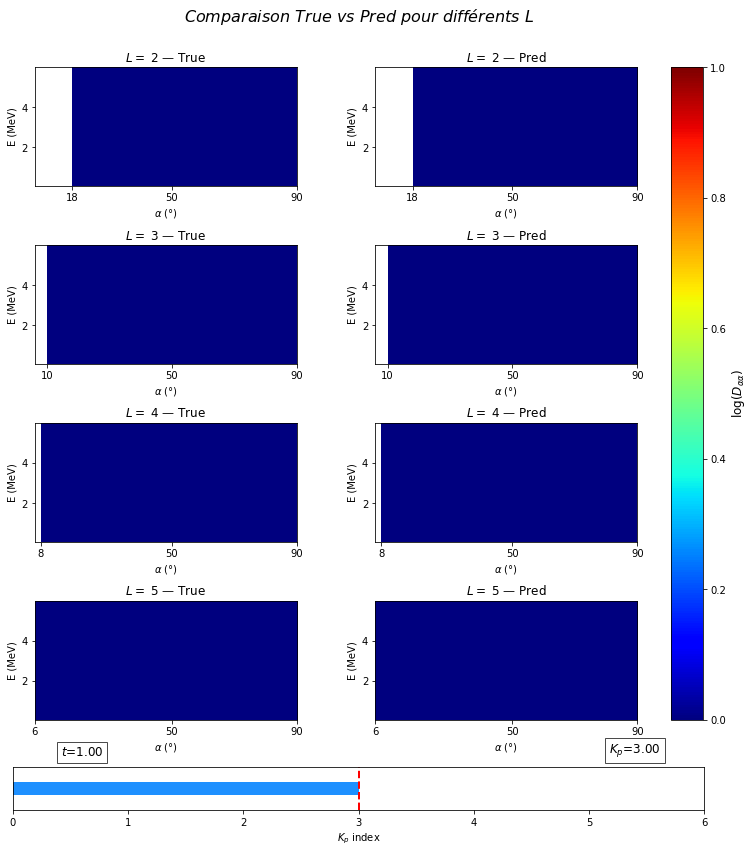

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm

def create_video_comparison(states_true_L,
                            states_pred_L,
                            y_spline,
                            filename="frame.png",
                            L_vals=[2,3,4,5]):
    """
    Affiche une frame statique avec les colonnes True / Pred pour tester l'UI/UX.
    
    Parameters
    ----------
    states_true_L : dict {L: ndarray(T, ny, nx)}
        Snapshots True.
    states_pred_L : dict {L: ndarray(T, ny, nx)}
        Snapshots Pred.
    y_spline : ndarray (T,)
        Valeurs de Kp.
    filename : str
        Nom de fichier si on veut sauvegarder l'image.
    L_vals : list
        Liste des L à afficher.
    """

    fig, axes_img = plt.subplots(
        len(L_vals), 2, figsize=(12, 12),
        gridspec_kw={'height_ratios':[1]*len(L_vals), 'width_ratios':[1,1]}
    )
    fig.suptitle("$Comparaison$ $True$ $vs$ $Pred$ $pour$ $différents$ $L$", fontsize=16, y=0.95)

    plt.subplots_adjust(hspace=0.5, wspace=0.3)

    # --- Barre Kp ---
    ax_kp = fig.add_axes([0.1, 0.02, 0.8, 0.05])
    ax_kp.set_xlim(0, 6)
    ax_kp.set_ylim(0, 1)
    ax_kp.set_yticks([])
    ax_kp.set_xlabel("$K_p$ index")

    bar = ax_kp.barh(0.5, y_spline[0], height=0.3, color='dodgerblue')
    kp_marker = ax_kp.axvline(y_spline[0], color='red', lw=2, linestyle='--')

    text_time = ax_kp.text(
        0.1, 1.2, f"$t$=1.00", ha='center', va='bottom', fontsize=12,
        transform=ax_kp.transAxes, bbox=dict(facecolor='white', alpha=0.7)
    )
    text_kp = ax_kp.text(
        0.9, 1.2, f"$K_p$={y_spline[0]:.2f}", ha='center', va='bottom', fontsize=12,
        transform=ax_kp.transAxes, bbox=dict(facecolor='white', alpha=0.7)
    )

    # --- Colorbar globale ---
    cNorm = colors.Normalize(vmin=0, vmax=1)
    cmap = cm.jet
    sm = cm.ScalarMappable(cmap=cmap, norm=cNorm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes_img.ravel().tolist(),
                        orientation='vertical', fraction=0.05, pad=0.05,
                        label=r"$\log(D_{\alpha\alpha})$")
    cbar.ax.yaxis.label.set_size(12)

    # --- Affichage frames ---
    alpha_min_dict = {2: 18, 3: 10, 4: 8, 5: 6}
    alpha_max = 90
    y1 = 10**(-1.13274599535844)
    y2 = 10**(0.777976150405938)

    for i, L in enumerate(L_vals):
        # Colonne gauche → True
        ax = axes_img[i, 0]
        ax.imshow(np.rot90(states_true_L[L][0], k=1), cmap=cmap, norm=cNorm,
                  aspect='auto', extent=[alpha_min_dict[L], alpha_max, y1, y2])
        ax.set_ylabel("E (MeV)")
        ax.set_xlabel(r"$\alpha$ (°)")
        ax.set_title(fr"$L =$ {L} — True")
        ax.set_xlim(6, alpha_max)
        ax.set_xticks([alpha_min_dict[L], 50, 90])
        ax.set_xticklabels([f"{v:d}" for v in [alpha_min_dict[L], 50, 90]])

        # Colonne droite → Pred
        ax = axes_img[i, 1]
        ax.imshow(np.rot90(states_pred_L[L][0], k=1), cmap=cmap, norm=cNorm,
                  aspect='auto', extent=[alpha_min_dict[L], alpha_max, y1, y2])
        ax.set_ylabel("E (MeV)")
        ax.set_xlabel(r"$\alpha$ (°)")
        ax.set_title(fr"$L =$ {L} — Pred")
        ax.set_xlim(6, alpha_max)
        ax.set_xticks([alpha_min_dict[L], 50, 90])
        ax.set_xticklabels([f"{v:d}" for v in [alpha_min_dict[L], 50, 90]])

    plt.show()


T = 1
L_vals = [2,3,4,5]
states_true_L = {L: np.zeros((T, 254, 60)) for L in L_vals}
states_pred_L = {L: np.zeros((T, 254, 60)) for L in L_vals}
y_spline = np.array([3.0])

create_video_comparison(states_true_L, states_pred_L, y_spline)


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, colors

def creation_video_comparison(states_true, states_pred, y_spline, filename="video_all_L.gif", fps=10):
    """
    Crée une vidéo comparant True vs Pred pour L = 2,3,4,5 avec une barre Kp.
    """

    L_vals = [2, 3, 4, 5]
    n_frames = y_spline.shape[0]

    fig, axes_img = plt.subplots(
        len(L_vals), 2, figsize=(12, 20),
        gridspec_kw={'height_ratios': [1]*len(L_vals), 'width_ratios':[1,1]}
    )

    fig.suptitle("$\log(D_{\\alpha\\alpha})$ $changes$ $over$ $time$", fontsize=16, y=0.92)
    plt.subplots_adjust(hspace=0.25, wspace=0.3)

    # --- Colorbar ---
    cNorm = colors.Normalize(vmin=-9, vmax=-4)
    cmap = plt.cm.jet
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=cNorm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes_img.ravel().tolist(),
                        orientation='vertical', fraction=0.1, pad=0.1,
                        label=r"$\log(D_{\alpha\alpha})$")
    cbar.ax.yaxis.label.set_size(14)

    # --- Axes pour la barre Kp ---
    ax_kp = fig.add_axes([0.1, 0.02, 0.8, 0.05])
    ax_kp.set_xlim(0, 6)
    ax_kp.set_ylim(0, 1)
    ax_kp.set_yticks([])
    ax_kp.set_xlabel("$K_p$ index")

    bar = ax_kp.barh(0.5, y_spline[0], height=0.3, color='dodgerblue')
    kp_marker = ax_kp.axvline(y_spline[0], color='red', lw=2, linestyle='--')

    text_time = ax_kp.text(0.1, 1.2, "", ha='center', va='bottom', fontsize=12,
                           transform=ax_kp.transAxes, bbox=dict(facecolor='white', alpha=0.7))
    text_kp = ax_kp.text(0.9, 1.2, "", ha='center', va='bottom', fontsize=12,
                         transform=ax_kp.transAxes, bbox=dict(facecolor='white', alpha=0.7))

    # --- Initialisation des images ---
    alpha_min_dict = {2: 18.8365, 3: 10.4515, 4: 7.6616, 5: 6.4779}
    alpha_max = 90
    y1 = 10**(-1.1327)
    y2 = 10**(0.77797)

    ims = []
    for i, L in enumerate(L_vals):
        # Colonne gauche → True
        ax = axes_img[i, 0]
        im = ax.imshow(np.rot90(states_true[L][0], k=1), cmap=cmap, norm=cNorm,
                       aspect='auto', extent=[alpha_min_dict[L], alpha_max, y1, y2])
        ax.set_ylabel("E (MeV)")
        ax.set_xlabel(r"$\alpha$ (°)")
        ax.set_title(fr"$L =$ {L} — True")
        ax.set_xlim(6.47, alpha_max)
        ax.set_xticks([alpha_min_dict[L], 50, 90])
        ax.set_xticklabels([f"{int(v)}" for v in [alpha_min_dict[L], 50, 90]])
        ims.append(im)

        # Colonne droite → Pred
        ax = axes_img[i, 1]
        im = ax.imshow(np.rot90(states_pred[L][0], k=1), cmap=cmap, norm=cNorm,
                       aspect='auto', extent=[alpha_min_dict[L], alpha_max, y1, y2])
        ax.set_ylabel("E (MeV)")
        ax.set_xlabel(r"$\alpha$ (°)")
        ax.set_title(fr"$L =$ {L} — Pred")
        ax.set_xlim(6.47, alpha_max)
        ax.set_xticks([alpha_min_dict[L], 50, 90])
        ax.set_xticklabels([f"{int(v)}" for v in [alpha_min_dict[L], 50, 90]])
        ims.append(im)

    # --- Fonction update ---
    def update(frame):
        t = 1 + 8 * frame / (n_frames - 1)
        Kp = y_spline[frame]

        for i, L in enumerate(L_vals):
            ims[2*i].set_array(np.rot90(states_true[L][frame], k=1))
            ims[2*i+1].set_array(np.rot90(states_pred[L][frame], k=1))

        bar[0].set_width(Kp)
        kp_marker.set_xdata(Kp)
        text_time.set_text(f"$t$ = {t:.2f}")
        text_kp.set_text(f"$K_p$ = {Kp:.2f}")

        return ims + [bar[0], kp_marker, text_time, text_kp]

    # --- Animation ---
    ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=100, blit=True)

    ani.save("video.gif", writer="pillow", fps=10, dpi=120)

    plt.close()
    print(f"Vidéo sauvegardée : {filename}")


In [33]:
import numpy as np

# Paramètres
L_vals = [2, 3, 4, 5]
n_frames = 10
ny, nx = 254, 60

# --- States True et Pred aléatoires ---
states_true = {L: np.random.rand(n_frames, ny, nx) for L in L_vals}
states_pred = {L: np.random.rand(n_frames, ny, nx) for L in L_vals}

# --- Valeurs Kp aléatoires ---
y_spline = np.random.rand(n_frames) * 6  # entre 0 et 6

# Vérification
print(states_true[2].shape)  # (10, 254, 60)
print(states_pred[3].shape)  # (10, 254, 60)
print(y_spline)              # tableau Kp
creation_video_comparison(states_true, states_pred, y_spline, filename="test_video.gif")


(10, 254, 60)
(10, 254, 60)
[3.02570985 3.7605363  4.43812018 3.13151952 5.52204716 2.97746124
 2.76956238 1.31449195 3.49500653 3.99022117]
Vidéo sauvegardée : test_video.gif
